In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [7]:
import os

# Dataset path
path = '/kaggle/input/animals10/raw-img'

# Folders
folders = os.listdir(path)
print(f"Total classes: {len(folders)}")
print(f"Classes: {folders}")

Total classes: 10
Classes: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


In [8]:
import shutil
import os

# Pehle purana folder remove
if os.path.exists('/kaggle/working/animals10'):
    shutil.rmtree('/kaggle/working/animals10')
    print("Purana folder hata diya! ✅")

# Ab dobara rename wala code
old_path = '/kaggle/input/animals10/raw-img'
new_path = '/kaggle/working/animals10'

translate = {
    'cane': 'dog',
    'gatto': 'cat',
    'cavallo': 'horse',
    'farfalla': 'butterfly',
    'elefante': 'elephant',
    'gallina': 'chicken',
    'mucca': 'cow',
    'pecora': 'sheep',
    'ragno': 'spider',
    'scoiattolo': 'squirrel'
}

for italian, english in translate.items():
    src = os.path.join(old_path, italian)
    dst = os.path.join(new_path, english)
    shutil.copytree(src, dst)
    print(f"{italian} → {english} ✅")


Purana folder hata diya! ✅
cane → dog ✅
gatto → cat ✅
cavallo → horse ✅
farfalla → butterfly ✅
elefante → elephant ✅
gallina → chicken ✅
mucca → cow ✅
pecora → sheep ✅
ragno → spider ✅
scoiattolo → squirrel ✅


In [9]:
folders = os.listdir(new_path)
print(f"Total classes: {len(folders)}")
print(f"Classes: {folders}")

Total classes: 10
Classes: ['chicken', 'squirrel', 'butterfly', 'cat', 'horse', 'sheep', 'elephant', 'spider', 'dog', 'cow']


In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


TRAINING DATA LOAD

In [19]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    new_path,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

print(f"Classes: {train_ds.class_names}")

Found 26179 files belonging to 10 classes.
Using 18326 files for training.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


VALIDATION DATA LOAD

In [12]:
val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    new_path,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)


Found 26179 files belonging to 10 classes.
Using 7853 files for validation.


VALIDATION AND TEST SEPERATE

In [13]:
total = tf.data.experimental.cardinality(val_test_ds).numpy()

val_size = int(total * 0.67)
test_size = int(total * 0.33)

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

print(f"Total batches: {total}")
print(f"Validation batches: {val_size}")
print(f"Test batches: {test_size}")

Total batches: 246
Validation batches: 164
Test batches: 81


SAMPLE IMAGES

In [14]:
class_names = train_ds.class_names

plt.figure(figsize=(15, 15))

for images, labels in train_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Sample Images", fontsize=20)
plt.show()

FAST DATASET

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)



DATA SEGMENTATION

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])


AUGMENTATION CHECK

MOBILE NET

In [22]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNet(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


print(f"Total layers: {len(base_model.layers)}")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers: 86


CUSTOMER LAYERS

In [23]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,354 (12.82 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

MODEL COMPILE

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


EARLY STOPPING

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


TRAIN MODEL

In [26]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping]
)


Epoch 1/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 59s 77ms/step - accuracy: 0.4195 - loss: 1.6675 - val_accuracy: 0.5196 - val_loss: 1.3804
Epoch 2/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.5080 - loss: 1.4036 - val_accuracy: 0.5808 - val_loss: 1.2472
Epoch 3/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.5396 - loss: 1.3199 - val_accuracy: 0.5837 - val_loss: 1.2232
Epoch 4/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.5611 - loss: 1.2601 - val_accuracy: 0.5985 - val_loss: 1.1797
Epoch 5/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.5780 - loss: 1.2149 - val_accuracy: 0.6071 - val_loss: 1.1627
Epoch 6/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.5880 - loss: 1.1877 - val_accuracy: 0.6044 - val_loss: 1.1612
Epoch 7/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.6036 - loss: 1.1524 - val_accuracy: 0.6073 - val_loss: 1.1579
Epoch 8/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.6055 - loss: 1.1307 - 

MODEL TEST

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - accuracy: 0.6326 - loss: 1.0850
Test Loss: 1.08
Test Accuracy: 63.26%


5 IMAGES PREDICTION

In [29]:
import matplotlib.pyplot as plt
import numpy as np


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


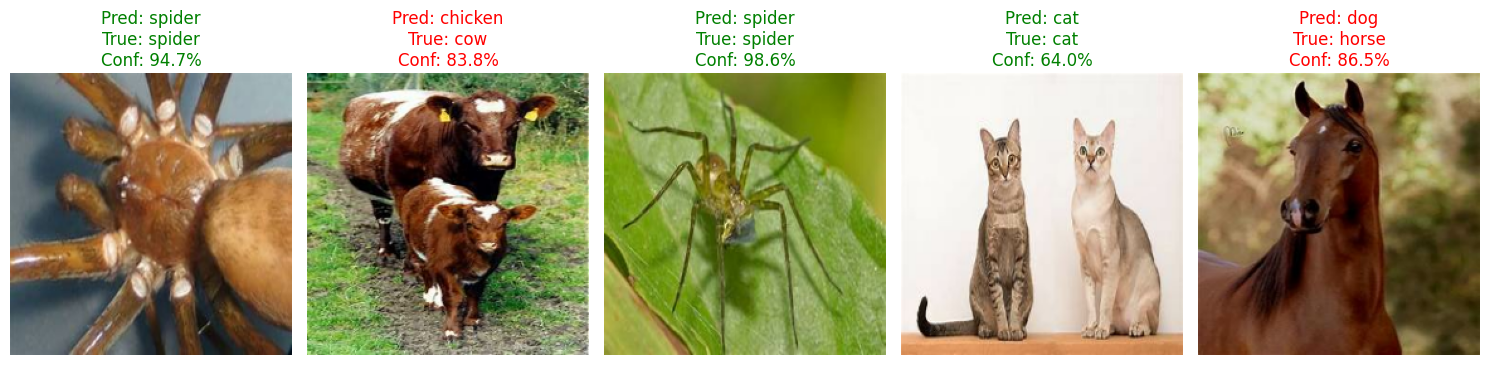

In [30]:
plt.figure(figsize=(15, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        pred_class = class_names[np.argmax(predictions[i])]
        true_class = class_names[labels[i]]
        confidence = np.max(predictions[i]) * 100

        color = "green" if pred_class == true_class else "red"

        plt.title(
            f"Pred: {pred_class}\n"
            f"True: {true_class}\n"
            f"Conf: {confidence:.1f}%",
            color=color
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

LOSS AND ACCURACY PLOT

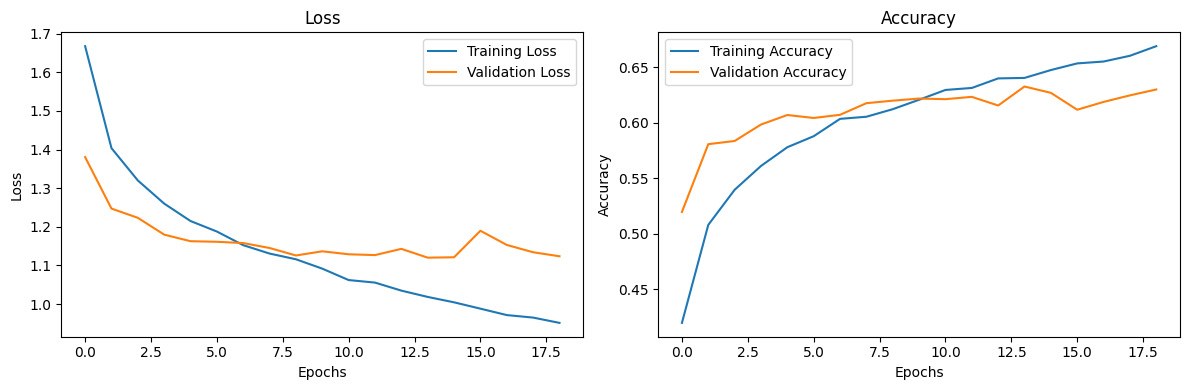

In [31]:
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()